# Python 기초 통계 - Day5 - Final Report & Presentation
이번 시간은 Day1 - Day4 기간 동안 배운 개념을 활용해 최종 데이터 분석 리포트를 작성하고 발표하는 시간입니다. 

여러분이 선정한 데이터로 아래의 과정을 수행함으로써 Python 기초 통계에서 배운 내용을 내재화하는 시간이 되시길 바랍니다. 

---
**[ 내용 구성 ]**

※ 아래의 내용이 포함되어야 합니다. 

### 1. 문제 정의 
    - 분석을 통해 검증하고자 하는 가설이나 얻고자 하는 결과물 설명.
    - 분류 문제인지 회귀 문제인지 설명. 
### 2. 데이터 EDA & 전처리
    - EDA: 데이터의 기본적인 shape을 파악하고, 기술통계량이나 분포를 다양한 시각화 차트로 표현.
    - 전처리: 중복값, 결측치, 잘못된 값 등이 없는지 확인하고 적절한 기법으로 처리.
### 3. 데이터 분석 기법 선정 이유
    - 가설검정, 선형회귀, 로지스틱회귀, 의사결정나무, K-means클러스터링 중에서 분석 기법을 선정하고 그 이유를 설명. 
### 4. 데이터 분석 모델링 (모델 구현)
    - 분석 모델 구현 및 결과 도출.
### 5. 분석 모델 결과 해석 및 인사이트 제안
    - 분석 모델 결과 해석 및 인사이트 제안
    - 해석 기법 (ex. 의사결정트리의 경우 plot_tree, feature_importance 사용, 선형회귀 모델의 경우 statsmodel summary report 활용 등.)
    
---
※ 샘플 데이터셋 링크 

1. 캐글 데이터셋 : https://www.kaggle.com/datasets
    - dataset메뉴에서 특정 분석 모델(ex. regression, clustering, etc.)을 검색하면 관련 데이터셋을 찾기 쉽습니다. 

2. UCI ML repository: https://archive.ics.uci.edu/

3. 공공데이터포털 : https://www.data.go.kr/

4. 서울 열린데이터광장 : https://data.seoul.go.kr/

5. aws open data registry : https://registry.opendata.aws/



## 1. 문제 정의 

위 데이터에서 price와 minimum_nights가 상관관계를 가지고 있는지 궁금했습니다. 

In [1]:
#데이터 셋 링크 : https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data/code?datasetId=268833
import pandas as pd
df=pd.read_csv("../Downloads/archive (16)/AB_NYC_2019.csv")
df.T

,0,1,2,3,4,5,6,7,8,9,...,48885,48886,48887,48888,48889,48890,48891,48892,48893,48894
id,2539,2595,3647,3831,5022,5099,5121,5178,5203,5238,...,36482809,36483010,36483152,36484087,36484363,36484665,36485057,36485431,36485609,36487245
name,Clean & quiet apt home by the park,Skylit Midtown Castle,THE VILLAGE OF HARLEM....NEW YORK !,Cozy Entire Floor of Brownstone,Entire Apt: Spacious Studio/Loft by central park,Large Cozy 1 BR Apartment In Midtown East,BlissArtsSpace!,Large Furnished Room Near B'way,Cozy Clean Guest Room - Family Apt,Cute & Cozy Lower East Side 1 bdrm,...,Stunning Bedroom NYC! Walking to Central Park!!,Comfy 1 Bedroom in Midtown East,Garden Jewel Apartment in Williamsburg New York,"Spacious Room w/ Private Rooftop, Central loca...",QUIT PRIVATE HOUSE,Charming one bedroom - newly renovated rowhouse,Affordable room in Bushwick/East Williamsburg,Sunny Studio at Historical Neighborhood,43rd St. Time Square-cozy single bed,Trendy duplex in the very heart of Hell's Kitchen
host_id,2787,2845,4632,4869,7192,7322,7356,8967,7490,7549,...,131529729,274311461,208514239,274321313,107716952,8232441,6570630,23492952,30985759,68119814
host_name,John,Jennifer,Elisabeth,LisaRoxanne,Laura,Chris,Garon,Shunichi,MaryEllen,Ben,...,Kendall,Scott,Melki,Kat,Michael,Sabrina,Marisol,Ilgar & Aysel,Taz,Christophe
neighbourhood_group,Brooklyn,Manhattan,Manhattan,Brooklyn,Manhattan,Manhattan,Brooklyn,Manhattan,Manhattan,Manhattan,...,Manhattan,Manhattan,Brooklyn,Manhattan,Queens,Brooklyn,Brooklyn,Manhattan,Manhattan,Manhattan
neighbourhood,Kensington,Midtown,Harlem,Clinton Hill,East Harlem,Murray Hill,Bedford-Stuyvesant,Hell's Kitchen,Upper West Side,Chinatown,...,East Harlem,Midtown,Williamsburg,Hell's Kitchen,Jamaica,Bedford-Stuyvesant,Bushwick,Harlem,Hell's Kitchen,Hell's Kitchen
latitude,40.64749,40.75362,40.80902,40.68514,40.79851,40.74767,40.68688,40.76489,40.80178,40.71344,...,40.79633,40.75561,40.71232,40.76392,40.69137,40.67853,40.70184,40.81475,40.75751,40.76404
longitude,-73.97237,-73.98377,-73.9419,-73.95976,-73.94399,-73.975,-73.95596,-73.98493,-73.96723,-73.99037,...,-73.93605,-73.96723,-73.9422,-73.99183,-73.80844,-73.94995,-73.93317,-73.94867,-73.99112,-73.98933
room_type,Private room,Entire home/apt,Private room,Entire home/apt,Entire home/apt,Entire home/apt,Private room,Private room,Private room,Entire home/apt,...,Private room,Entire home/apt,Entire home/apt,Private room,Private room,Private room,Private room,Entire home/apt,Shared room,Private room
price,149,225,150,89,80,200,60,79,79,150,...,75,200,170,125,65,70,40,115,55,90


## 2. 데이터 EDA

In [2]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [3]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [4]:
df.fillna(0).isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.drop(columns=['id','name','host_name','neighbourhood','neighbourhood_group','room_type','last_review']).groupby(['price']).min()

,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,,,,,,,,
0,1641537,40.68173,-73.97597,1,0,0.05,1,0
10,647528,40.66242,-73.99817,1,0,0.07,1,0
11,19342,40.68994,-73.96315,1,0,3.86,1,245
12,1144452,40.67405,-74.01590,1,0,0.59,1,0
13,158178970,40.63136,-74.12559,1,9,5.51,3,8
...,...,...,...,...,...,...,...,...
7703,156158778,40.76824,-73.95989,1,0,NaN,12,146
8000,1177497,40.69137,-73.96723,1,1,0.03,11,365
8500,18128455,40.72197,-74.00633,30,2,0.18,1,251


In [7]:
df.drop(columns=['id','name','host_name','neighbourhood','neighbourhood_group','room_type','last_review']).groupby(['price']).mean()

,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,,,,,,,,
0,5.862573e+07,40.712058,-73.925670,7.363636,34.272727,1.7370,4.272727,120.909091
10,9.768142e+07,40.729329,-73.936397,4.058824,14.176471,1.3075,1.235294,70.705882
11,1.051506e+08,40.738027,-73.925720,3.333333,37.666667,3.8600,1.000000,259.666667
12,2.886539e+07,40.714980,-73.970378,76.750000,2.000000,0.5900,1.000000,99.000000
13,1.581790e+08,40.631360,-74.125590,1.000000,9.000000,5.5100,3.000000,8.000000
...,...,...,...,...,...,...,...,...
7703,1.561588e+08,40.768240,-73.959890,1.000000,0.000000,NaN,12.000000,146.000000
8000,1.177497e+06,40.691370,-73.967230,1.000000,1.000000,0.0300,11.000000,365.000000
8500,1.812846e+07,40.721970,-74.006330,30.000000,2.000000,0.1800,1.000000,251.000000


In [8]:
df.drop(columns=['id','name','host_name','neighbourhood','neighbourhood_group','room_type','last_review']).groupby(['price']).max()

,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,,,,,,,,
0,131697576,40.83296,-73.88668,30,95,4.37,6,333
10,268138154,40.83454,-73.79886,30,93,4.73,4,332
11,205706382,40.79900,-73.89845,7,113,3.86,1,273
12,108512889,40.74045,-73.92095,300,8,0.59,1,359
13,158178970,40.63136,-74.12559,1,9,5.51,3,8
...,...,...,...,...,...,...,...,...
7703,156158778,40.76824,-73.95989,1,0,NaN,12,146
8000,1177497,40.69137,-73.96723,1,1,0.03,11,365
8500,18128455,40.72197,-74.00633,30,2,0.18,1,251


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


## 3. 데이터 분석 기법 선정 이유와 얻고자 하는 아웃풋

In [10]:
#price 와 minimum_nights의 상관관계를 알기위해 상관분석 사용
#하지만 상관관계가 너무 약함 
#공분산
covariance = df['price'].cov(df['minimum_nights'])
covariance

210.81642314540218

In [11]:
from scipy.stats import pearsonr
pearson_corr, p_value = pearsonr(df['price'], df['minimum_nights'])
print('price 와 minimum_nights의 피어슨 상관계수: ', f"{pearson_corr:.10f}")

alpha = 0.05

if p_value < alpha:
    print("귀무가설 기각. \n통계적으로 유의미한 수준으로 연관성이 있음.")
else:
    print("귀무가설 기각할 수 없음. \n통계적으로 유의미한 수준으로 연관성이 없음.")

price 와 minimum_nights의 피어슨 상관계수:  0.0427993341
귀무가설 기각. 
통계적으로 유의미한 수준으로 연관성이 있음.


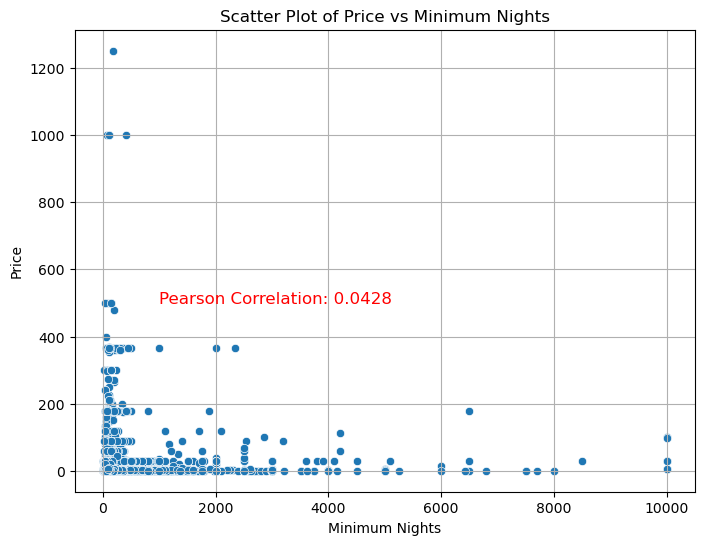

In [12]:
#상관계수 시각
import seaborn as sns
import matplotlib.pyplot as plt

# 산점도와 상관계수 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='price', y='minimum_nights')
plt.title('Scatter Plot of Price vs Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Price')
plt.text(1000, 500, f'Pearson Correlation: {pearson_corr:.4f}', fontsize=12, color='red')
plt.grid(True)
plt.show()

C:\Users\BIG3-07\.anaconda1001\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(0.0, 1250.0)

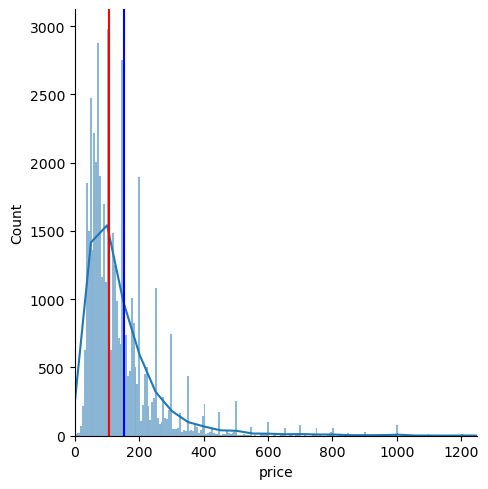

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

## Price의 확률밀도함수
sns.displot(df['price'], kde=True)

## 평균, 중간값 수직선
plt.axvline(df['price'].mean(), color='blue')  
plt.axvline(df['price'].median(), color='red')
plt.xlim(0,1250)

## 4. 데이터 분석 모델링 (가설검정, 선형회귀, 로지스틱회귀, 의사결정나무, K-means클러스터링 중에서 선택)

In [14]:
#선형회귀 선택 연관이 유의미한 연관이 없더라도 결과값이 궁금했습니다. 피어슨 상관계수의 값이 많이 작기 때문입니다.
# 단순선형회귀 (Simple Linear Regression)
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 독립 변수(X)
X = df['minimum_nights']
y = df['price']  # 종속 변수

# Add constant term to input for intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Predict
y_pred = model.predict(X)

# Calculate R-squared
r_squared = model.rsquared

# Calculate MAE
mae = mean_absolute_error(y, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))

# Summary report with p-values
summary = model.summary()

print("R-squared:", r_squared)
print("MAE:", mae)
print("RMSE:", rmse)
print(summary)

R-squared: 0.0018317830031103766
MAE: 92.31065079681231
RMSE: 239.93166018669191
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     89.73
Date:                Wed, 14 Feb 2024   Prob (F-statistic):           2.85e-21
Time:                        11:21:14   Log-Likelihood:            -3.3734e+05
No. Observations:               48895   AIC:                         6.747e+05
Df Residuals:                   48893   BIC:                         6.747e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

In [15]:
#결과 분석 
columns_ = ['col_names', 'coef', 'std err', 't', 'P>|t|', '[0.025', '0.975]']
p_values_table = pd.DataFrame(summary.tables[1].data[1:], columns=columns_)
p_values_table[columns_[1:]] = p_values_table[columns_[1:]].astype(float)
(p_values_table)

,col_names,coef,std err,t,P>|t|,[0.025,0.975]
0,const,149.1978,1.147,130.070,0.0,146.950,151.446
1,minimum_nights,0.5011,0.053,9.472,0.0,0.397,0.605


In [16]:
#하지만 올바른 분석을 위해 가설검정을 해보겠습니다.
from scipy.stats import ttest_ind
import scipy.stats as stats
# Create two groups based on gender (male and female)
short_stays= df[df['minimum_nights'] < 7]['price']
long_stays = df[df['minimum_nights'] >= 7]['price']

# Perform two-sample t-test
t_statistic, p_value = ttest_ind(short_stays, long_stays, equal_var=False)  # Assuming unequal variances

# Print the results
print("T-statistic:", t_statistic)
print("P-value:", p_value)

# Degrees of freedom (df) for a two-sample t-test is (n1 + n2 - 2), where n1 and n2 are the sample sizes of the two groups
df1 = len(short_stays) + len(long_stays) - 2

# Find the critical value for a two-tailed test
critical_value = stats.t.ppf(1 - alpha/2, df1)
print("Critical Value:", critical_value)

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("귀무가설 기각. \n두 그룹의 평균이 통계적으로 유의미한 차이가 있다.")
else:
    print("귀무가설 기각 할 수 없음. \n두 그룹의 평균이 통계적으로 유의미한 차이가 없음. ")

# Effect Size (cohen's d)
import numpy as np
def cohens_d(group1, group2):
    mean_difference = np.mean(group1) - np.mean(group2)
    pooled_std = np.sqrt((np.var(group1) + np.var(group2)) / 2)
    return mean_difference / pooled_std

cohen_d = cohens_d(short_stays, long_stays)
print("=================\n")
print("short_stays_mean: ", short_stays.mean())
print("long_stays_mean: ", long_stays.mean())
if cohen_d <= 0.2: 
    print("Cohen's d:", cohen_d)
    print("Cohen's d 효과 크기가 작으므로 두 그룹의 차이가 크지 않다고 볼 수 있음.")
    
elif cohen_d < 0.8:
    print("Cohen's d:", cohen_d)
    print("Cohen's d 효과 크기가 중간 정도로 두 그룹의 차이가 적지 않다고 볼 수 있음.")
    
elif cohen_d >= 0.8:
    print("Cohen's d:", cohen_d)
    print("Cohen's d 효과 크기가 크므로 두 그룹의 차이가 크다고 볼 수 있음.")

T-statistic: -3.5551424549595354
P-value: 0.0003793125984062197
Critical Value: 1.960012505370427
귀무가설 기각. 
두 그룹의 평균이 통계적으로 유의미한 차이가 있다.

short_stays_mean:  150.28878088294857
long_stays_mean:  162.9506974763071
Cohen's d: -0.0456478186192096
Cohen's d 효과 크기가 작으므로 두 그룹의 차이가 크지 않다고 볼 수 있음.


## 5. 분석 결과 해석 및 인사이트 제안

# 선형회귀 모델
-R-squared(결정계수)가 낮습니다. 종속 변수와 독립변수가 상관관계를 가지고 있지만 모델을 잘 설명하지 못하고 있습니다.

-회귀계수가 약 0.5입니다. 독립변수가 증가함에 따라 종속 변수의 변화량이 0.5만큼 변화합니.

-p-value의 값이 유의수준 보다 작기때문에 통계적으로 유의미합니다.

# 가설검정
- t-statistics가 -3.5수준입니다.  t-통계량의 절대값이 critical value보다 크고, p-value가 유의수준보다 작으면, 귀무가설을 기각할 수 있습니다.
- 효과 크기가 크지 않습니다. 즉 7일을 기준으로 더 묵은 가격과 덜 묵은 가격 차이가 크지 않다고 볼 수 있습니다.

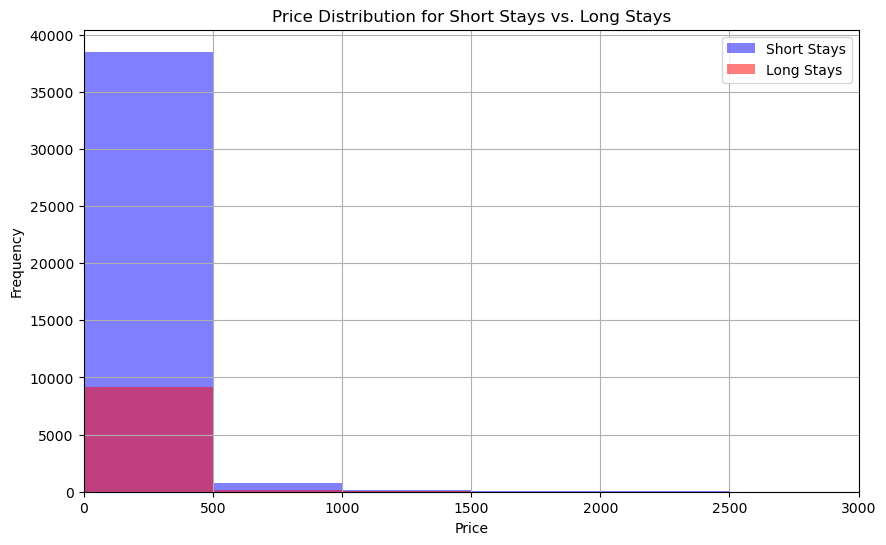

In [17]:
#귀무가설 시각화
import matplotlib.pyplot as plt

# 시각화를 위한 히스토그램
plt.figure(figsize=(10, 6))
plt.hist(short_stays, bins=20, alpha=0.5, color='blue', label='Short Stays')
plt.hist(long_stays, bins=20, alpha=0.5, color='red', label='Long Stays')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution for Short Stays vs. Long Stays')
plt.legend()
plt.grid(True)
plt.xlim(0,3000)
plt.show()


---

**감사합니다. 모두 고생 많으셨습니다.**

👏👏👏👏👏

---